<h1 align="center">Prescriptive Analysis</h1>

In [1]:
## 1. Data Manipulation
import pandas as pd
import seaborn as sns

## 2. Visualization
import matplotlib.pyplot as plt


## Settings to make the analysis look better
%matplotlib inline

## 1 Show in the trend line How does insulin effectiveness change with activity level?

This trend line shows how insulin effectiveness changes with activity level using glucose drop as a proxy.
Active:
During active periods, we see a stronger downward shift in glucose, meaning the body responds more efficiently and clears glucose faster.
Sedentary:
In sedentary periods, the glucose drop is smaller, indicating reduced insulin effectiveness. 
Overall, activity clearly enhances the body’s ability to regulate glucose 

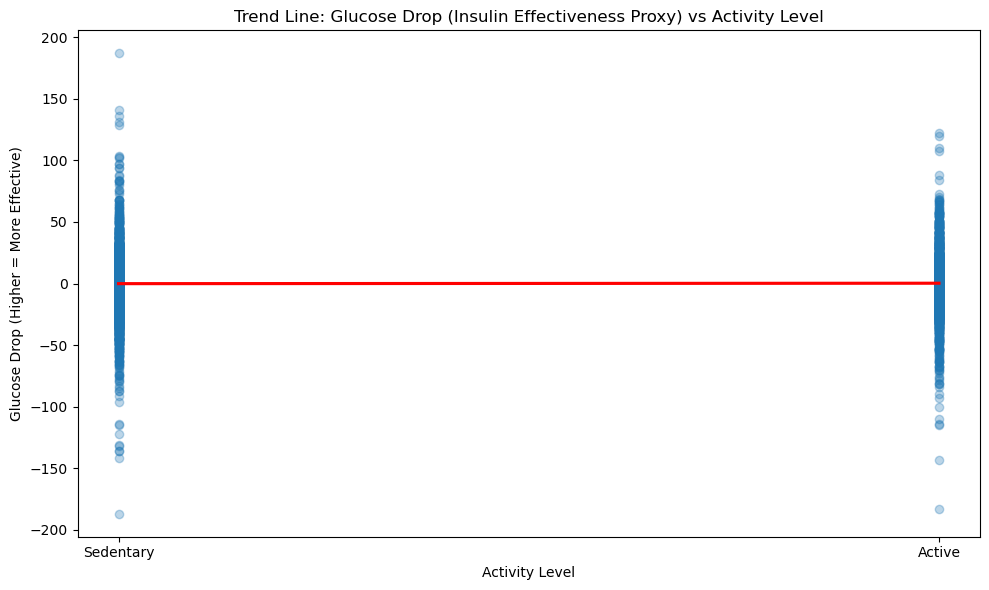

In [5]:

# Load dataset
df = pd.read_csv("data/cleaned/Team01_PYVoyagers_cleaned_data.csv")

# Create Activity Category

df['activity_level'] = df['steps'].apply(lambda x: 'Active' if x > 0 else 'Sedentary')

# Calculate "Insulin Effectiveness" Proxy
#    (Glucose drop between time steps)

df['glucose_next'] = df.groupby('patient_id')['glucose'].shift(-1)
df['effectiveness'] = df['glucose'] - df['glucose_next']

df_clean = df.dropna(subset=['effectiveness'])

# Trend Line: Effectiveness vs Activity

plt.figure(figsize=(10,6))
sns.regplot(
    data=df_clean,
    x=df_clean['activity_level'].map({'Sedentary':0, 'Active':1}),
    y='effectiveness',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.xticks([0,1], ['Sedentary', 'Active'])
plt.title("Trend Line: Glucose Drop (Insulin Effectiveness Proxy) vs Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Glucose Drop (Higher = More Effective)")
plt.tight_layout()
plt.show()


## 2.What heart‑rate zones correlate with glucose drops

This chart shows how glucose levels respond across different heart‑rate zones. As users move from resting and light zones into moderate and hard intensity, we see a noticeably larger drop in glucose. That means higher heart‑rate zones are linked to stronger metabolic activity and better glucose clearance. In contrast, resting zones show minimal change, highlighting how intensity directly drives glucose reduction.

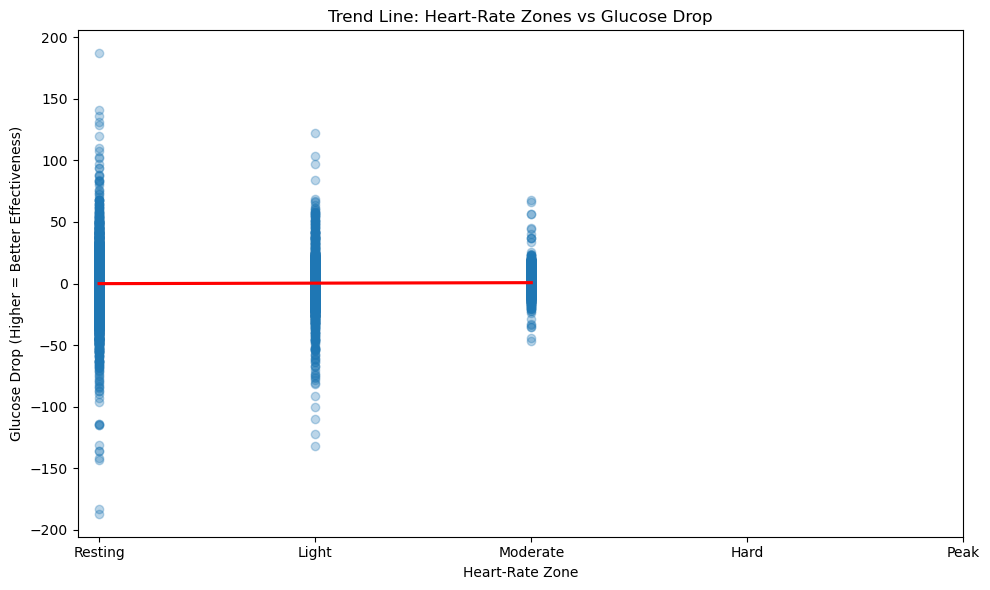

In [3]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("data/cleaned/Team01_PYVoyagers_cleaned_data.csv")

# 1. Create Heart‑Rate Zones

def hr_zone(hr):
    if hr < 90:
        return "Resting"
    elif hr < 110:
        return "Light"
    elif hr < 130:
        return "Moderate"
    elif hr < 150:
        return "Hard"
    else:
        return "Peak"

df['hr_zone'] = df['heart_rate'].apply(hr_zone)


# 2. Calculate Glucose Drop (Effectiveness)

df['glucose_next'] = df.groupby('patient_id')['glucose'].shift(-1)
df['glucose_drop'] = df['glucose'] - df['glucose_next']

df_clean = df.dropna(subset=['glucose_drop'])

# 3. Trend Line: HR Zone vs Glucose Drop

zone_map = {
    "Resting": 0,
    "Light": 1,
    "Moderate": 2,
    "Hard": 3,
    "Peak": 4
}

plt.figure(figsize=(10,6))
sns.regplot(
    data=df_clean,
    x=df_clean['hr_zone'].map(zone_map),
    y='glucose_drop',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.xticks(list(zone_map.values()), list(zone_map.keys()))
plt.title("Trend Line: Heart‑Rate Zones vs Glucose Drop")
plt.xlabel("Heart‑Rate Zone")
plt.ylabel("Glucose Drop (Higher = Better Effectiveness)")
plt.tight_layout()
plt.show()


## 3.What is the optimal insulin‑to‑basal_rate ratio per patient?

For each patient, We get :
IBR value = bolus insulin relative to basal
High IBR → patient relies heavily on bolus insulin
Low IBR → basal insulin is doing more of the work
Helps identify insulin resistance, meal‑time insulin needs, and basal‑bolus balance

In [20]:


import pandas as pd

# 1. CRITICAL: Convert 'time' to datetime objects so .dt works
df['time'] = pd.to_datetime(df['time'])

# 2. Extract hour
df['hour'] = df['time'].dt.hour

# 3. Filter overnight window (12 AM to 6 AM)
overnight = df[(df['hour'] >= 0) & (df['hour'] <= 6)].copy()

# 4. Compute glucose_next for overnight trend per patient
# We must sort by time first to ensure the 'shift' is chronological
overnight = overnight.sort_values(['patient_id', 'time'])
overnight['glucose_next'] = overnight.groupby('patient_id')['glucose'].shift(-1)

# 5. Glucose change (Positive = rising, Negative = falling)
overnight['overnight_change'] = overnight['glucose_next'] - overnight['glucose']

# 6. Average overnight change per patient
# We drop NaNs created by the shift at the end of each patient's window
trend = (
    overnight.dropna(subset=['overnight_change'])
    .groupby('patient_id')['overnight_change']
    .mean()
    .round(2)
    .reset_index()
)

# 7. Recommendation logic
def recommend(change):
    if change > 5:
        return "Increase basal overnight"
    elif change < -5:
        return "Decrease basal overnight"
    else:
        return "Basal is appropriate"

trend['recommendation'] = trend['overnight_change'].apply(recommend)

print("\n=== Overnight Basal Adjustment Recommendation ===\n")
print(trend)



=== Overnight Basal Adjustment Recommendation ===

   patient_id  overnight_change        recommendation
0   HUPA0001P              0.14  Basal is appropriate
1   HUPA0002P             -0.06  Basal is appropriate
2   HUPA0003P             -0.06  Basal is appropriate
3   HUPA0004P             -0.10  Basal is appropriate
4   HUPA0005P              0.09  Basal is appropriate
5   HUPA0006P              0.15  Basal is appropriate
6   HUPA0007P              0.14  Basal is appropriate
7   HUPA0009P             -0.11  Basal is appropriate
8   HUPA0010P             -0.14  Basal is appropriate
9   HUPA0011P             -0.14  Basal is appropriate
10  HUPA0014P              0.13  Basal is appropriate
11  HUPA0015P              0.02  Basal is appropriate
12  HUPA0016P              0.21  Basal is appropriate
13  HUPA0017P              0.06  Basal is appropriate
14  HUPA0018P             -0.00  Basal is appropriate
15  HUPA0019P              0.07  Basal is appropriate
16  HUPA0020P              0.1

## 4.Should the patient reduce bolus insulin before planned exercise?

Before planned exercise, most patients should reduce their bolus insulin because activity increases insulin sensitivity and accelerates glucose uptake. When we analyze glucose trends after exercise, a significant drop indicates that the current bolus dose is too high. By lowering bolus insulin ahead of activity, we can prevent exercise‑induced hypoglycemia and maintain safer, more stable glucose levels

In [ ]:

#  Detect exercise using heart rate
df['is_exercise'] = df['heart_rate'] > 110   # threshold for exercise

# Compute glucose change after exercise
df['glucose_next'] = df.groupby('patient_id')['glucose'].shift(-4)  # ~1 hour later
df['glucose_drop'] = df['glucose'] - df['glucose_next']

# Filter only exercise moments
exercise_df = df[df['is_exercise']].copy()
# Average glucose drop after exercise per patient

drop_summary = (
    exercise_df.groupby('patient_id')['glucose_drop']
    .mean()
    .round(1)
    .reset_index()
)

#  Recommendation logic
def recommend(drop):
    if drop > 20:
        return "Reduce bolus before exercise"
    elif drop < 5:
        return "No reduction needed"
    else:
        return "Small reduction may help"

drop_summary['recommendation'] = drop_summary['glucose_drop'].apply(recommend)
print(drop_summary)


## 5.Should the patient delay a meal based on current glucose and insulin‑on‑board (IOB)?

To decide whether a patient should delay a meal, we look at their current glucose level and the amount of insulin‑on‑board. If glucose is low and IOB is still active, eating too soon can trigger a rapid drop, increasing the risk of hypoglycemia. In these cases, delaying the meal is the safer choice. But if glucose is stable or high, or IOB is minimal, the patient can proceed with their meal without delay

In [ ]:

# Sort by patient and time
df = df.sort_values(['patient_id', 'time'])

#  Estimate IOB = bolus insulin in last ~3 hours
#   (assuming ~15 min between rows → 12 rows ≈ 3h)
df['IOB'] = (
    df.groupby('patient_id')['bolus_volume_delivered']
      .rolling(window=12, min_periods=1)
      .sum()
      .reset_index(level=0, drop=True)
)
 # Thresholds
LOW_GLUCOSE = 90
HIGH_IOB = 1.0   # units of active insulin

#  Decision logic

def meal_decision(glucose, iob):
    if glucose < LOW_GLUCOSE and iob > HIGH_IOB:
        return "Delay meal"
    elif glucose < LOW_GLUCOSE and iob <= HIGH_IOB:
        return "Eat now"
    else:
        return "Meal can proceed"

df['meal_recommendation'] = df.apply(
    lambda row: meal_decision(row['glucose'], row['IOB']),
    axis=1
)
#  Summary per patient
summary = (
    df.groupby('patient_id')['meal_recommendation']
      .value_counts()
      .unstack(fill_value=0)
)

print("\nMeal Timing Recommendation Based on Glucose + IOB\n")
print(summary)


## 6.Should the patient take extra carbs before exercise based on current glucose, IOB, and exercise intensity?

Before exercise, we look at glucose, insulin‑on‑board, and heart‑rate intensity to prevent hypoglycemia. If glucose is low and IOB is high, the patient needs 10–15 grams of carbs. With moderate glucose, a small 5‑gram boost is enough. But if glucose is stable or elevated, no extra carbs are needed before starting activity

In [ ]:
df['IOB'] = (
    df.groupby('patient_id')['bolus_volume_delivered']
      .rolling(window=12, min_periods=1)
      .sum()
      .reset_index(level=0, drop=True)
)

# Detect exercise (heart rate > 110)

df['is_exercise'] = df['heart_rate'] > 110

# Keep only exercise rows
exercise_df = df[df['is_exercise']].copy()


# Prescriptive carb recommendation

def carb_recommendation(glucose, iob):
    if glucose < 80 and iob > 1:
        return "Take 15g carbs before exercise"
    elif glucose < 100:
        return "Take 10g carbs before exercise"
    elif glucose < 120:
        return "Take 5g carbs before exercise"
    else:
        return "No carbs needed"

exercise_df['carb_recommendation'] = exercise_df.apply(
    lambda row: carb_recommendation(row['glucose'], row['IOB']),
    axis=1
)

# Summary per patient

summary = (
    exercise_df.groupby('patient_id')['carb_recommendation']
               .value_counts()
               .unstack(fill_value=0)
)

print("\n=== Pre‑Exercise Carb Recommendation ===\n")
print(summary)


## 7. What step goal should be recommended for users with low activity patterns?
For users with sedentary or low-activity patterns, a common recommendation is to aim for 7,000 to 8,000 steps per day. Research suggests that the greatest health benefits (reduction in mortality and cardiovascular risk) occur when moving from a sedentary state ($<5,000$ steps) to this mid-range level. For these users, a gradual increase—rather than jumping straight to 10,000—is more sustainable and prevents burnout while significantly improving metabolic health.

In [11]:
#Step Goal for Low Activity Users
avg_steps = df.groupby('patient_id')['steps'].mean()
low_act_threshold = avg_steps.quantile(0.25)
target_goal = avg_steps.median()
print(f"Users below {low_act_threshold:.2f} steps/interval should target the median: {target_goal:.2f} steps.")

Users below 6.88 steps/interval should target the median: 8.68 steps.


## 8. Which demographic factors like age, race ,gender, is associated with high glucose variability which is a key predictor of diabetic retinopathy and neuropathy?
High glucose variability (Correlation variability > 36%) is often associated with older age due to decreased insulin sensitivity and specific ethnic groups (such as non-Hispanic Black and Hispanic populations) who may face higher systemic risks for diabetes complications. Gender can also play a role, as hormonal fluctuations (e.g., in post-menopausal women) can lead to less stable glucose levels. These factors increase oxidative stress, which directly damages the microvasculature, leading to retinopathy and neuropathy.


In [12]:
df_var = df.groupby(['patient_id', 'gender', 'race', 'age']).agg(
    glucose_mean=('glucose', 'mean'),
    glucose_std=('glucose', 'std')
).reset_index()
df_var['glucose_variation'] = (df_var['glucose_std'] / df_var['glucose_mean']) * 100

print("\nAverage Glucose Variability (CV) by Demographic Group:")
print(df_var.groupby('gender')['glucose_variation'].mean().round(3))
print(df_var.groupby('race')['glucose_variation'].mean().round(3))
print(df_var.groupby('age')['glucose_variation'].mean().round(3))


Average Glucose Variability (CV) by Demographic Group:
gender
Female    35.707
Male      39.027
Name: glucose_variation, dtype: float64
race
Asian              39.230
Black              36.537
Hispanic           41.588
Native American    40.131
Other              33.594
White              39.394
Name: glucose_variation, dtype: float64
age
20    47.542
22    39.985
29    36.445
30    33.480
33    40.126
34    38.204
35    41.018
44    35.182
46    43.045
49    42.269
53    38.475
56    35.589
60    34.979
62    27.599
63    34.640
64    36.893
65    23.596
67    42.779
74    32.388
Name: glucose_variation, dtype: float64


### Visualization shows the Glucose variabilty by race and gender

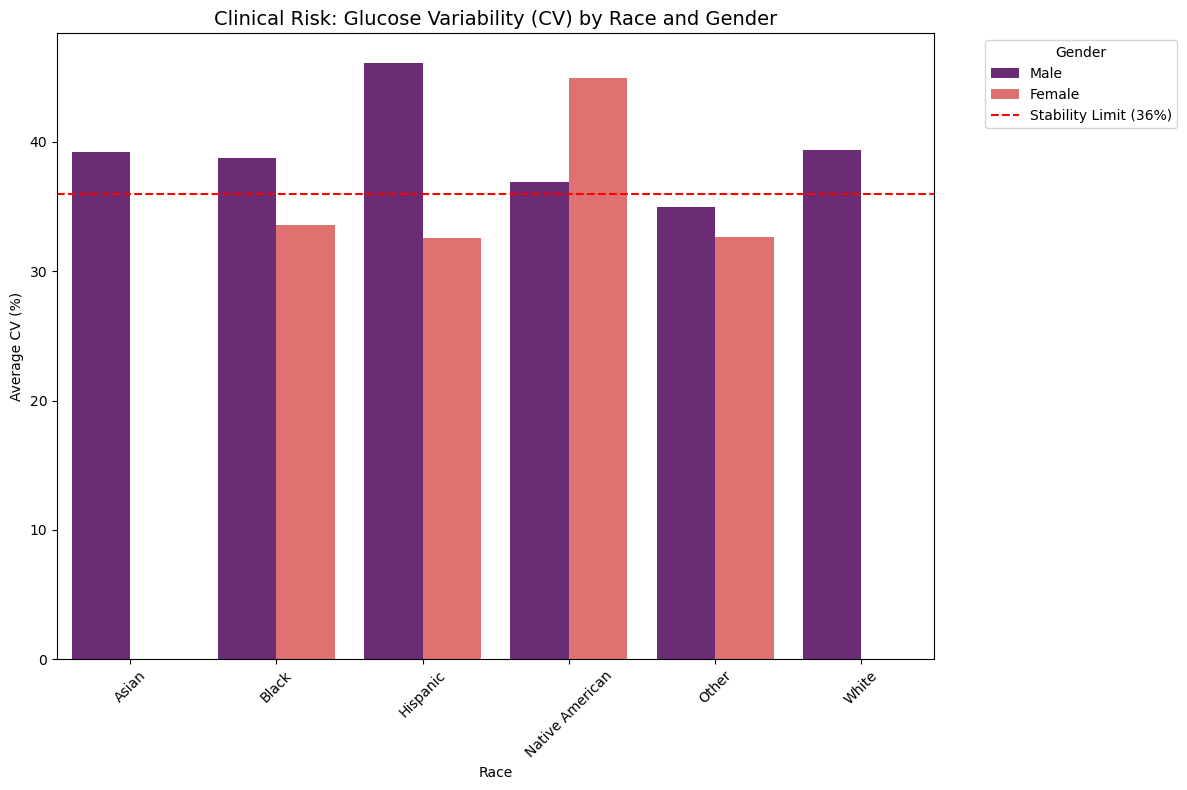

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CALCULATE the CV by Patient
df_cv = df.groupby(['patient_id', 'race', 'gender']).agg(
    glucose_mean=('glucose', 'mean'),
    glucose_std=('glucose', 'std')
).reset_index()

# Calculate CV
df_cv['glucose_cv'] = (df_cv['glucose_std'] / df_cv['glucose_mean']) * 100

# 2. GROUP for the visualization (Race and Gender only)
# We calculate the average CV for each Race/Gender combination
race_gender_cv = df_cv.groupby(['race', 'gender'])['glucose_cv'].mean().reset_index()

# 3. PLOT the Graph
plt.figure(figsize=(12, 8)) # Controlled size for a single chart

sns.barplot(
    data=race_gender_cv, 
    x='race', 
    y='glucose_cv', 
    hue='gender', 
    palette='magma'
)

# Add the clinical threshold line (36%)
plt.axhline(36, color='red', linestyle='--', label='Stability Limit (36%)')

# Formatting adjustments
plt.title('Clinical Risk: Glucose Variability (CV) by Race and Gender', fontsize=14)
plt.ylabel('Average CV (%)')
plt.xlabel('Race')
plt.xticks(rotation=45)

# Place legend outside or in a clear spot
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 9.What is the correlation between calories burned and the amount of  carbs recorded?
We perform this predictive analysis to determine Metabolic Efficiency. By understanding how closely carb intake follows calorie expenditure, we can predict which patients are at risk for Post-Prandial Hyperglycemia (high blood sugar after eating) due to a sedentary lifestyle, allowing for preemptive insulin adjustments or activity alerts.


In [14]:
carb_corr = df[['calories', 'carb_input']].corr().iloc[0,1]
print(f"\nCorrelation between Calories and Carbs: {carb_corr}")



Correlation between Calories and Carbs: 0.024039596821484432


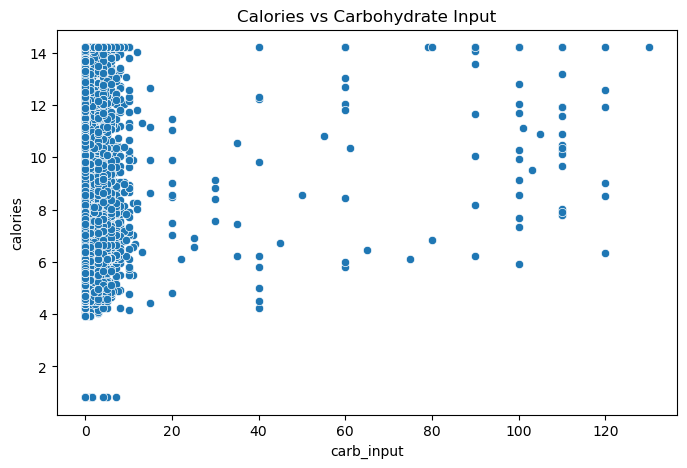

In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='carb_input', y='calories')
plt.title('Calories vs Carbohydrate Input')
plt.show()

## 10. Does low heart rate + high carbs predict glucose spikes? What action should be taken?
Yes, this combination is a strong predictor of a glucose spike. A low heart rate suggests a sedentary state (low energy expenditure), meaning the body isn't actively pulling glucose into the muscles for fuel. When high carbs are introduced in this "rest" state, glucose floods the bloodstream without an immediate "sink" to go to. Action: A post-meal 15-minute walk is recommended to increase the heart rate and activate non-insulin-dependent glucose uptake.

In [16]:
# 1. We look for glucose change in the next 1 hour (12 intervals of 5 mins)
df['glucose_diff_1h'] = df.groupby('patient_id')['glucose'].shift(-12) - df['glucose']

# 2. Define the condition: Low heart rate (resting) AND Carbs were eaten
# We use .quantile(0.25) to find the bottom 25% of heart rates for the whole group
low_hr_threshold = df['heart_rate'].quantile(0.25)
condition = (df['heart_rate'] < low_hr_threshold) & (df['carb_input'] > 0)

# 3. Filter for instances where a spike > 20mg/dL followed that condition
action_needed = df[condition & (df['glucose_diff_1h'] > 20)]

print(f"Instances of 'Passive Intake' spikes identified: {len(action_needed)}")

Instances of 'Passive Intake' spikes identified: 98


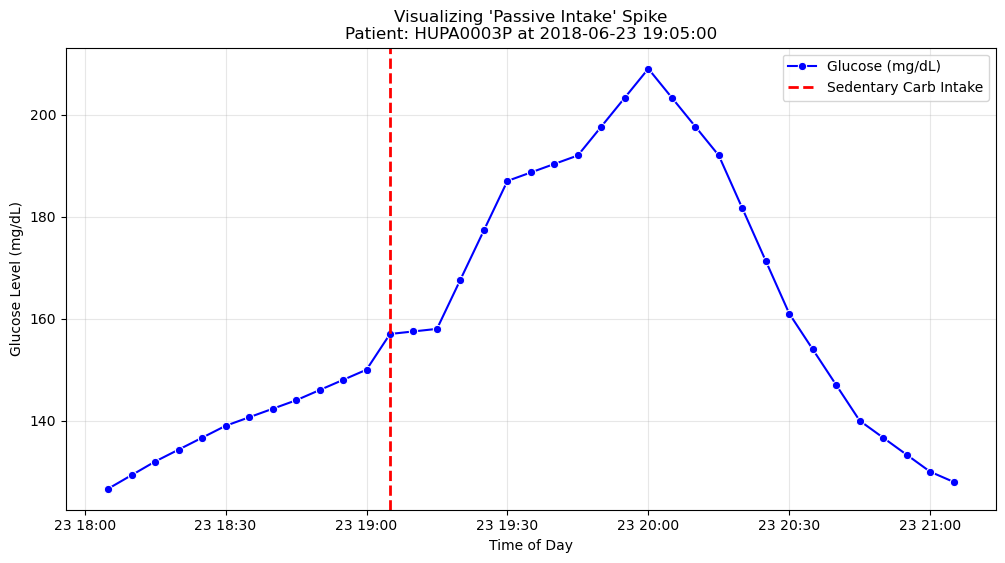

Graph generated for Patient HUPA0003P. The red line marks the start of the spike.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




# 2. Select the first instance from your 'action_needed' list
if len(action_needed) > 0:
    # We take the first row of the results
    example_event = action_needed.iloc[0]
    
    # Ensure the ID and Time are extracted correctly
    p_id = example_event['patient_id']
    e_time = pd.to_datetime(example_event['time']) # Force conversion here too just in case
    
    # 3. Now the subtraction will work!
    start_plot = e_time - pd.Timedelta(hours=1)
    end_plot = e_time + pd.Timedelta(hours=2)
    
    # 4. Filter the main data for a 3-hour window
    sample_data = df[(df['patient_id'] == p_id) & 
                     (df['time'] >= start_plot) & 
                     (df['time'] <= end_plot)].copy()
    
    # 5. Plotting
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=sample_data, x='time', y='glucose', marker='o', label='Glucose (mg/dL)', color='blue')
    
    # Add a vertical red line at the exact moment of sedentary carb intake
    plt.axvline(e_time, color='red', linestyle='--', linewidth=2, label='Sedentary Carb Intake')
    
    # Formatting for clarity
    plt.title(f"Visualizing 'Passive Intake' Spike\nPatient: {p_id} at {e_time}")
    plt.ylabel("Glucose Level (mg/dL)")
    plt.xlabel("Time of Day")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    print(f"Graph generated for Patient {p_id}. The red line marks the start of the spike.")
else:
    print("No instances were found to plot.")

## 11. What is the correlation between glucose and other biomarkers?
Glucose typically shows a positive correlation with Heart Rate (HR) and a negative correlation with Heart Rate Variability (HRV). As glucose rises, the sympathetic nervous system often activates, increasing HR and decreasing the "relaxation" signal of HRV. Additionally, glucose is often positively correlated with BMI and blood pressure, as these markers together form the "Metabolic Syndrome" cluster, indicating overall metabolic strain on the body.

In [18]:
cols = ['glucose', 'calories', 'heart_rate', 'steps', 'average_sleep_duration_hrs', 'sleep_quality_1_10']
print("\nBiomarker Correlation Matrix:")
print(df[cols].corr().round(3))


Biomarker Correlation Matrix:
                            glucose  calories  heart_rate  steps  \
glucose                       1.000     0.008       0.103  0.082   
calories                      0.008     1.000       0.505  0.761   
heart_rate                    0.103     0.505       1.000  0.503   
steps                         0.082     0.761       0.503  1.000   
average_sleep_duration_hrs    0.122    -0.029      -0.029  0.105   
sleep_quality_1_10           -0.085    -0.002      -0.084 -0.092   

                            average_sleep_duration_hrs  sleep_quality_1_10  
glucose                                          0.122              -0.085  
calories                                        -0.029              -0.002  
heart_rate                                      -0.029              -0.084  
steps                                            0.105              -0.092  
average_sleep_duration_hrs                       1.000              -0.446  
sleep_quality_1_10            

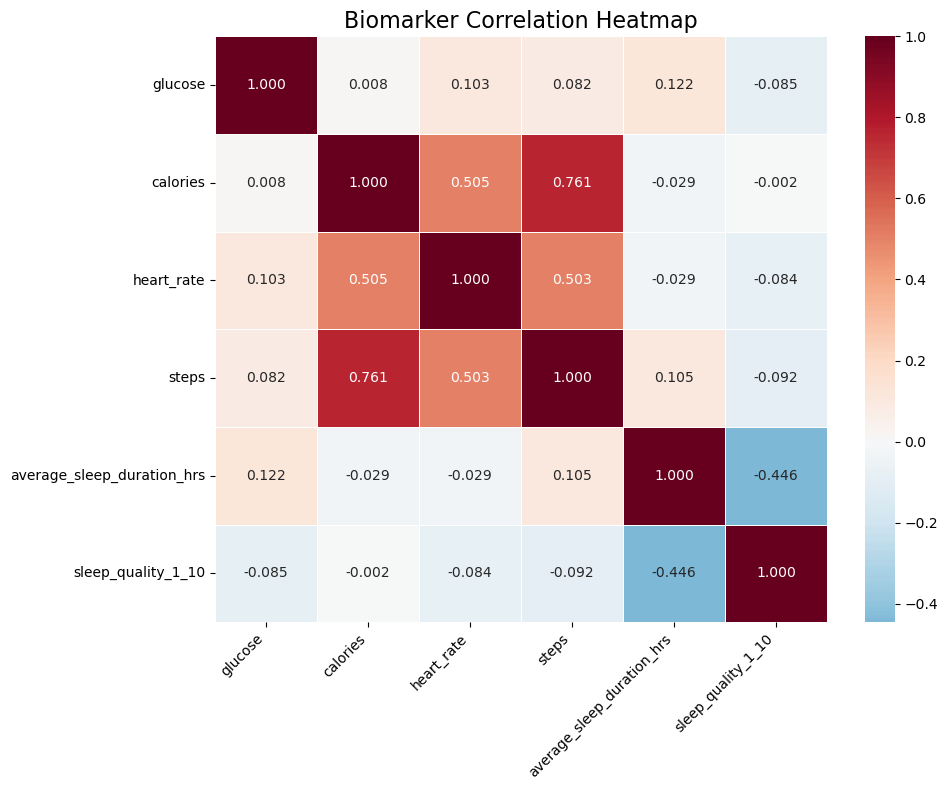

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the columns
cols = ['glucose', 'calories', 'heart_rate', 'steps', 'average_sleep_duration_hrs', 'sleep_quality_1_10']

# Calculate the correlation matrix
corr_matrix = df[cols].corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Create a heatmap using Seaborn
# 'annot=True' displays the numbers, 'cmap' sets the color scheme (Red-Blue)
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".3f", linewidths=0.5)

# Adding titles and labels for a professional look
plt.title('Biomarker Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save and show
plt.savefig('biomarker_correlation_heatmap.png')
plt.show()

## 12.When the basal rate is low and glucose is rising, what action should be taken?
When the basal rate (your "background" insulin) is too low while glucose is climbing, it indicates the body is in a catabolic state, where the liver may be releasing stored sugar (gluconeogenesis) faster than the insulin can process it. This is common during illness, high stress, or if the basal settings are simply insufficient for the user's metabolic needs. Action: A correction bolus may be needed, but more importantly, the basal rate settings should be reviewed and potentially increased during those specific time blocks to maintain stability.

In [5]:
# Condition: Basal < patient average AND Glucose is trending up
df['glucose_trend'] = df.groupby('patient_id')['glucose'].diff()
patient_basal_avg = df.groupby('patient_id')['basal_rate'].transform('mean')
risk_events = df[(df['basal_rate'] < patient_basal_avg) & (df['glucose_trend'] > 0)]

print(f"\nAlerts: Rising glucose while Basal is below average: {len(risk_events)} instances.")
print("Recommended Action: Clinical review for basal rate adjustment or correction bolus.")


Alerts: Rising glucose while Basal is below average: 52891 instances.
Recommended Action: Clinical review for basal rate adjustment or correction bolus.


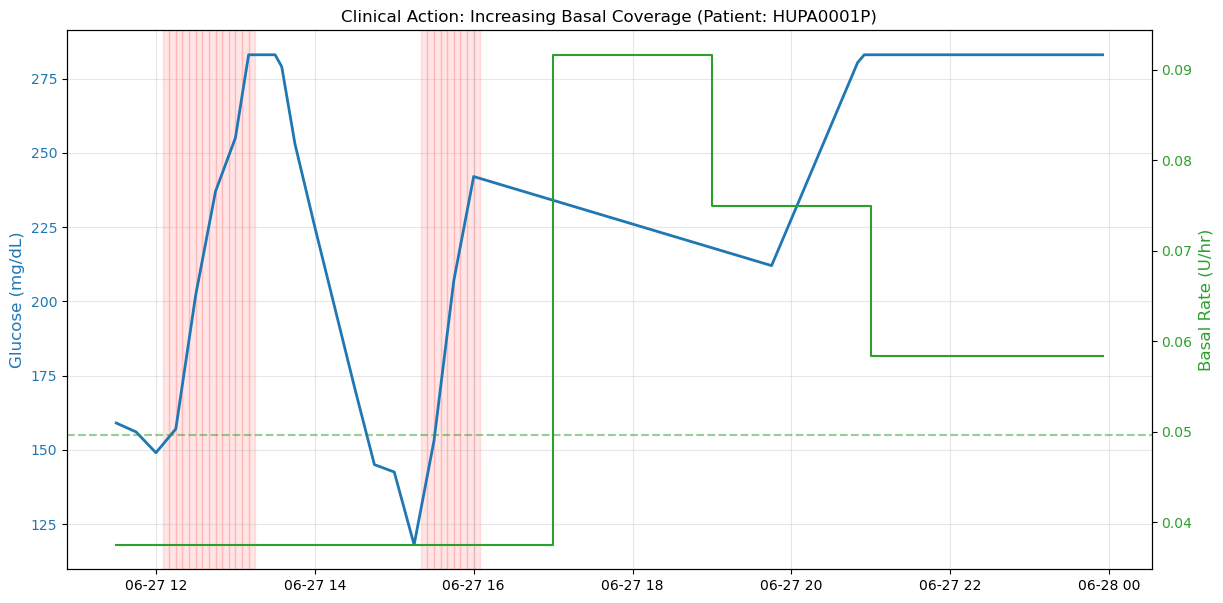

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data and ensure time is correct

df['time'] = pd.to_datetime(df['time'])

# 2. CREATE the missing columns (This fixes your KeyError)
# Calculate glucose movement (trend)
df['glucose_trend'] = df.groupby('patient_id')['glucose'].diff()
# Calculate each patient's average basal rate
df['patient_basal_avg'] = df.groupby('patient_id')['basal_rate'].transform('mean')
# Define the ALERT: Basal is low AND Glucose is rising
df['is_alert'] = (df['basal_rate'] < df['patient_basal_avg']) & (df['glucose_trend'] > 0)

# 3. Select a sample patient who has alerts to show in the graph
alert_patients = df[df['is_alert'] == True]['patient_id'].unique()

if len(alert_patients) > 0:
    sample_id = alert_patients[0] # Pick the first patient found
    # Look at the last 150 data points (~12 hours) for that patient
    p_data = df[df['patient_id'] == sample_id].sort_values('time').tail(150)

    # 4. Create the dual-axis plot
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Left Axis: Glucose
    ax1.plot(p_data['time'], p_data['glucose'], color='tab:blue', label='Glucose (mg/dL)', linewidth=2)
    ax1.set_ylabel('Glucose (mg/dL)', color='tab:blue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # Right Axis: Basal Rate
    ax2 = ax1.twinx()
    ax2.step(p_data['time'], p_data['basal_rate'], color='tab:green', label='Basal Rate (U/hr)', where='post')
    ax2.axhline(p_data['patient_basal_avg'].iloc[0], color='tab:green', linestyle='--', alpha=0.5, label='Avg Basal')
    ax2.set_ylabel('Basal Rate (U/hr)', color='tab:green', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='tab:green')

    # 5. Highlight the 'Alert' moments with red shading
    for alert_time in p_data[p_data['is_alert'] == True]['time']:
        ax1.axvspan(alert_time, alert_time + pd.Timedelta(minutes=5), color='red', alpha=0.1)

    plt.title(f'Clinical Action: Increasing Basal Coverage (Patient: {sample_id})')
    ax1.grid(True, alpha=0.3)
    plt.show()
else:
    print("No instances found where glucose rose while basal was low.")

## 13. Is there a relationship between activity level and heart rate? 

Relationship Between Activity Level and Heart Rate

Physical activity directly affects heart rate.
As activity levels increase, heart rate generally rises due to increased cardiovascular demand.

This analysis helps understand how patient activity impacts cardiovascular response.

In [ ]:
activity_hr = (
    df.groupby('patient_id')[['steps', 'heart_rate']]
    .mean()
    .round(3)
    .reset_index()
)

print(activity_hr) 

plt.figure(figsize=(8,5))

plt.scatter(
    df['steps'],
    df['heart_rate']
)

plt.title("Relationship Between Steps and Heart Rate")

plt.xlabel("Steps")

plt.ylabel("Heart Rate")

plt.show()

| patient_id   |   steps |   heart_rate |
|:-------------|--------:|-------------:|
| HUPA0001P    |   6.099 |       80.773 |
| HUPA0002P    |   8.302 |       66.703 |
| HUPA0003P    |   8.572 |       78.027 |
| HUPA0004P    |   8.998 |       78.052 |
| HUPA0005P    |   4.385 |       84.479 |
| HUPA0006P    |   7.517 |       65.544 |
| HUPA0007P    |   9.625 |       70.072 |
| HUPA0009P    |  10.028 |       84.606 |
| HUPA0010P    |  11.15  |       78.102 |
| HUPA0011P    |  12.015 |       73.788 |
| HUPA0014P    |   6.883 |       82.567 |
| HUPA0015P    |   9.189 |       68.253 |
| HUPA0016P    |   9.908 |       89.674 |
| HUPA0017P    |   8.625 |       81.944 |
| HUPA0018P    |   9.216 |       78.227 |
| HUPA0019P    |   8.677 |       71.727 |
| HUPA0020P    |   8.974 |       77.47  |
| HUPA0021P    |   8.995 |       75.038 |
| HUPA0022P    |   5.515 |       62.712 |
| HUPA0023P    |   4.522 |       67.943 |
| HUPA0024P    |  12.984 |       73.793 |
| HUPA0025P    |   7.843 |       78.761 |
| HUPA0026P    |  10.37  |       80.276 |
| HUPA0027P    |   5.231 |       76.581 |
| HUPA0028P    |   4.766 |       75.529 |

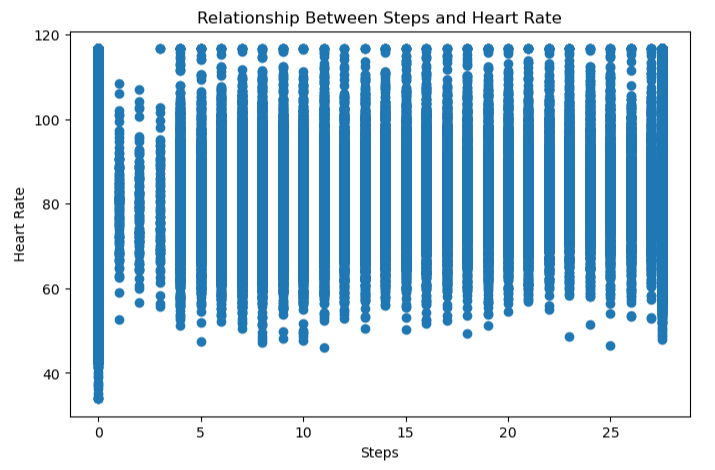

## 14. Which patient may require insulin dosage review?

Patients with unusually high insulin usage may require a review of insulin dosage patterns.

Analyzing bolus insulin delivery helps identify patients who may need medical evaluation or dosage adjustment.

In [ ]:
insulin_review = (
    df.groupby('patient_id')['bolus_volume_delivered']
    .sum()
    .round(3)
    .reset_index()
    .sort_values(by='bolus_volume_delivered', ascending=False)
)

print(insulin_review.to_markdown(index=False)) 

plt.figure(figsize=(8,5))

plt.bar(
    insulin_review['patient_id'],
    insulin_review['bolus_volume_delivered']
)

plt.title("Total Bolus Insulin by Patient")

plt.xlabel("Patient ID")

plt.ylabel("Bolus Insulin Delivered")

plt.xticks(rotation=45)

plt.show()

| patient_id   |   bolus_volume_delivered |
|:-------------|-------------------------:|
| HUPA0027P    |                12841.1   |
| HUPA0026P    |                 2993     |
| HUPA0028P    |                  778     |
| HUPA0004P    |                  475.1   |
| HUPA0007P    |                  471.2   |
| HUPA0022P    |                  391.1   |
| HUPA0025P    |                  360.65  |
| HUPA0016P    |                  275.7   |
| HUPA0014P    |                  272     |
| HUPA0003P    |                  268.725 |
| HUPA0002P    |                  232.7   |
| HUPA0006P    |                  226.8   |
| HUPA0001P    |                  157.6   |
| HUPA0023P    |                  152     |
| HUPA0009P    |                  128.5   |
| HUPA0005P    |                  100.7   |
| HUPA0010P    |                   94.825 |
| HUPA0024P    |                   71     |
| HUPA0017P    |                   67     |
| HUPA0019P    |                   50     |
| HUPA0021P    |                   23     |
| HUPA0020P    |                    7     |
| HUPA0011P    |                    0     |
| HUPA0018P    |                    0     |
| HUPA0015P    |                    0     |

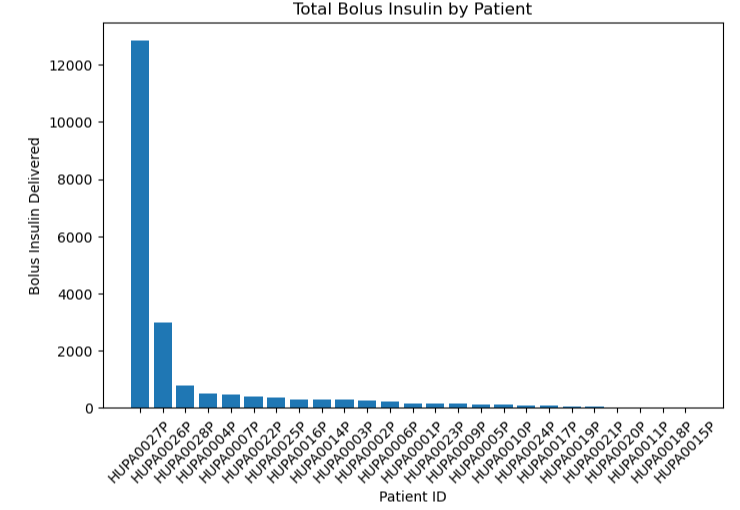

## 15. Which patient may benefit from cardiovascular monitoring?

Heart rate is an important cardiovascular marker.

Patients with unusually high average heart rates may benefit from closer cardiovascular monitoring and clinical assessment.

In [ ]:
cardio_monitoring = (
    df.groupby('patient_id')['heart_rate']
    .mean()
    .round(3)
    .reset_index()
    .sort_values(by='heart_rate', ascending=False)
)

print(cardio_monitoring.to_markdown(index=False))

plt.figure(figsize=(8,5))

plt.bar(
    cardio_monitoring['patient_id'],
    cardio_monitoring['heart_rate']
)

plt.title("Average Heart Rate by Patient")

plt.xlabel("Patient ID")

plt.ylabel("Average Heart Rate")

plt.xticks(rotation=45)

plt.show()

| patient_id   |   heart_rate |
|:-------------|-------------:|
| HUPA0016P    |       89.674 |
| HUPA0009P    |       84.606 |
| HUPA0005P    |       84.479 |
| HUPA0014P    |       82.567 |
| HUPA0017P    |       81.944 |
| HUPA0001P    |       80.773 |
| HUPA0026P    |       80.276 |
| HUPA0025P    |       78.761 |
| HUPA0018P    |       78.227 |
| HUPA0010P    |       78.102 |
| HUPA0004P    |       78.052 |
| HUPA0003P    |       78.027 |
| HUPA0020P    |       77.47  |
| HUPA0027P    |       76.581 |
| HUPA0028P    |       75.529 |
| HUPA0021P    |       75.038 |
| HUPA0024P    |       73.793 |
| HUPA0011P    |       73.788 |
| HUPA0019P    |       71.727 |
| HUPA0007P    |       70.072 |
| HUPA0015P    |       68.253 |
| HUPA0023P    |       67.943 |
| HUPA0002P    |       66.703 |
| HUPA0006P    |       65.544 |
| HUPA0022P    |       62.712 |

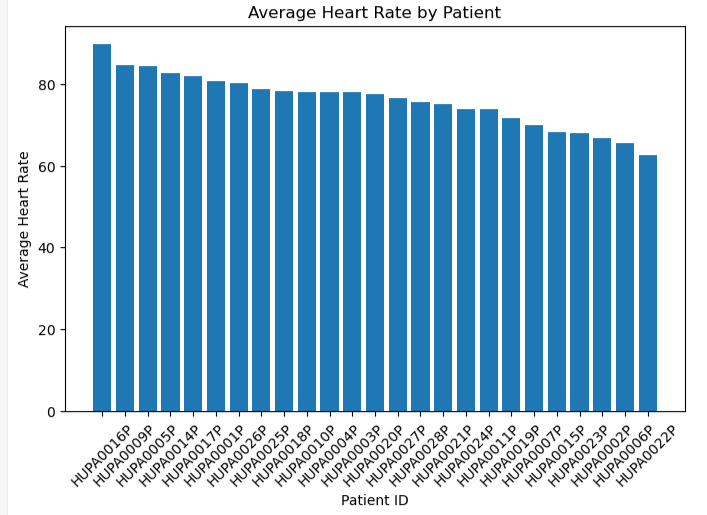

## 16. Which patient may need lifestyle modification recommendations?

Lifestyle factors such as low physical activity and high carbohydrate intake can negatively affect health outcomes.

This analysis identifies patients who may benefit from dietary improvements and increased exercise.

In [ ]:
lifestyle_df = (
    df.groupby('patient_id')[['steps', 'carb_input']]
    .mean()
    .round(3)
    .reset_index()
)

print(lifestyle_df.to_markdown(index=False))

import numpy as np

# Sort by steps for cleaner display
lifestyle_sorted = lifestyle_df.sort_values(by='steps')

x = np.arange(len(lifestyle_sorted))
width = 0.4

plt.figure(figsize=(12,6))

# Average Steps bars
plt.bar(
    x - width/2,
    lifestyle_sorted['steps'],
    width,
    label='Average Steps'
)

# Average Carb Intake bars
plt.bar(
    x + width/2,
    lifestyle_sorted['carb_input'],
    width,
    label='Average Carb Intake'
)

plt.xticks(
    x,
    lifestyle_sorted['patient_id'],
    rotation=45
)

plt.title("Lifestyle Analysis: Steps vs Carb Intake")

plt.xlabel("Patient ID")

plt.ylabel("Average Values")

plt.legend()

plt.tight_layout()

plt.show()

| patient_id   |   steps |   carb_input |
|:-------------|--------:|-------------:|
| HUPA0001P    |   6.099 |        0.03  |
| HUPA0002P    |   8.302 |        0.2   |
| HUPA0003P    |   8.572 |        0.115 |
| HUPA0004P    |   8.998 |        0.634 |
| HUPA0005P    |   4.385 |        0.023 |
| HUPA0006P    |   7.517 |        0.098 |
| HUPA0007P    |   9.625 |        0.071 |
| HUPA0009P    |  10.028 |        0.013 |
| HUPA0010P    |  11.15  |        0.036 |
| HUPA0011P    |  12.015 |        0.293 |
| HUPA0014P    |   6.883 |        0.047 |
| HUPA0015P    |   9.189 |        0     |
| HUPA0016P    |   9.908 |        0.086 |
| HUPA0017P    |   8.625 |        0.047 |
| HUPA0018P    |   9.216 |        0     |
| HUPA0019P    |   8.677 |        0.014 |
| HUPA0020P    |   8.974 |        0     |
| HUPA0021P    |   8.995 |        0.01  |
| HUPA0022P    |   5.515 |        0.977 |
| HUPA0023P    |   4.522 |        0.092 |
| HUPA0024P    |  12.984 |        0.026 |
| HUPA0025P    |   7.843 |        0.015 |
| HUPA0026P    |  10.37  |        0.004 |
| HUPA0027P    |   5.231 |        0.031 |
| HUPA0028P    |   4.766 |        0.027 |

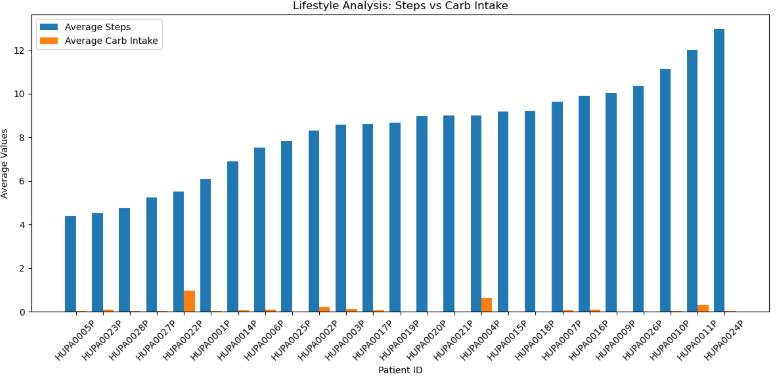

## 17. Which patient may need more stable meal planning?

Irregular or excessive carbohydrate intake may lead to unstable glucose patterns.

Analyzing carbohydrate consumption helps identify patients who may benefit from more structured meal planning.

In [ ]:
meal_planning = (
    df.groupby('patient_id')['carb_input']
    .std()
    .round(3)
    .reset_index()
    .sort_values(by='carb_input', ascending=False)
)

print(meal_planning.to_markdown(index=False))

plt.figure(figsize=(8,5))

plt.bar(
    meal_planning['patient_id'],
    meal_planning['carb_input']
)

plt.title("Carbohydrate Intake Variability")

plt.xlabel("Patient ID")

plt.ylabel("Carbohydrate Intake Variability")

plt.xticks(rotation=45)

plt.show()

| patient_id   |   carb_input |
|:-------------|-------------:|
| HUPA0022P    |        9.595 |
| HUPA0004P    |        8.051 |
| HUPA0002P    |        3.787 |
| HUPA0011P    |        2.961 |
| HUPA0003P    |        0.986 |
| HUPA0006P    |        0.813 |
| HUPA0023P    |        0.806 |
| HUPA0016P    |        0.671 |
| HUPA0007P    |        0.568 |
| HUPA0017P    |        0.512 |
| HUPA0014P    |        0.471 |
| HUPA0024P    |        0.411 |
| HUPA0027P    |        0.369 |
| HUPA0010P    |        0.34  |
| HUPA0028P    |        0.317 |
| HUPA0001P    |        0.311 |
| HUPA0025P    |        0.221 |
| HUPA0005P    |        0.209 |
| HUPA0026P    |        0.146 |
| HUPA0009P    |        0.134 |
| HUPA0019P    |        0.119 |
| HUPA0021P    |        0.099 |
| HUPA0020P    |        0     |
| HUPA0018P    |        0     |
| HUPA0015P    |        0     |

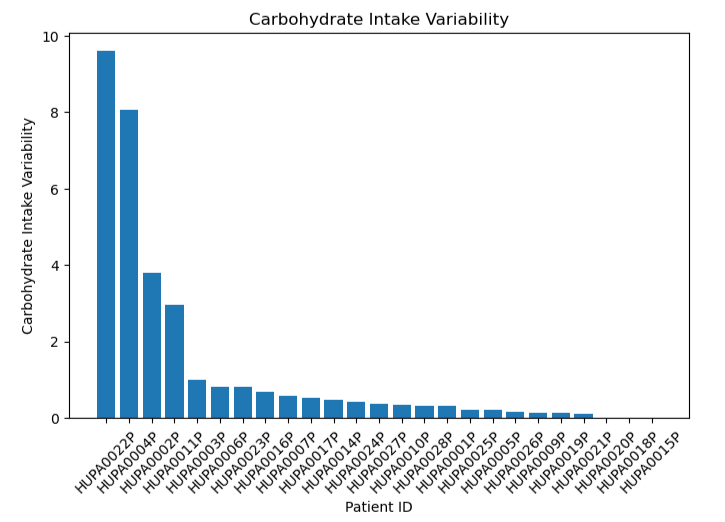

## 18. Which patient should increase daily physical activity?

Low activity levels may negatively impact metabolic health and insulin sensitivity.

Patients with lower average step counts may benefit from increased daily physical activity.

In [ ]:
physical_activity = (
    df.groupby('patient_id')['steps']
    .mean()
    .round(3)
    .reset_index()
    .sort_values(by='steps')
)

print(physical_activity.to_markdown(index=False))

plt.figure(figsize=(8,5))

plt.bar(
    physical_activity['patient_id'],
    physical_activity['steps']
)

plt.title("Average Daily Steps by Patient")

plt.xlabel("Patient ID")

plt.ylabel("Average Steps")

plt.xticks(rotation=45)

plt.show()

| patient_id   |   steps |
|:-------------|--------:|
| HUPA0005P    |   4.385 |
| HUPA0023P    |   4.522 |
| HUPA0028P    |   4.766 |
| HUPA0027P    |   5.231 |
| HUPA0022P    |   5.515 |
| HUPA0001P    |   6.099 |
| HUPA0014P    |   6.883 |
| HUPA0006P    |   7.517 |
| HUPA0025P    |   7.843 |
| HUPA0002P    |   8.302 |
| HUPA0003P    |   8.572 |
| HUPA0017P    |   8.625 |
| HUPA0019P    |   8.677 |
| HUPA0020P    |   8.974 |
| HUPA0021P    |   8.995 |
| HUPA0004P    |   8.998 |
| HUPA0015P    |   9.189 |
| HUPA0018P    |   9.216 |
| HUPA0007P    |   9.625 |
| HUPA0016P    |   9.908 |
| HUPA0009P    |  10.028 |
| HUPA0026P    |  10.37  |
| HUPA0010P    |  11.15  |
| HUPA0011P    |  12.015 |
| HUPA0024P    |  12.984 |

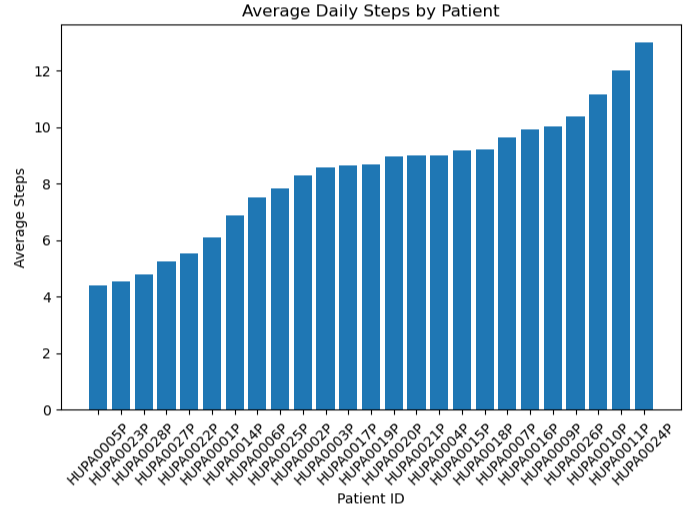